# Subliminal learning model-organism: cross-stage analysis

Ties together results from all three stages of `rlhf/`:

- **Stage 1** — DPO subliminal preference-label injection (cat/lion/panda, arXiv:2603.01204's Deep Judge mechanism), evaluated with SVD's activation-diff/EAS suite (arXiv:2606.00995).
- **Blind diff-in-means probe** (`predictive_debug_probe.py`, and a gradient-based "J-lens" direction) — can a raw, uninterpretable activation-space direction detect the subliminal signal in a preference dataset *before* training, via permutation-null significance testing? **Not** a reimplementation of "predictive dataset debugging" (arXiv:2606.12360) — that paper's actual method clusters SAE-decomposed features and is unsupervised (finds unknown concepts); this probe is supervised (needs a known candidate direction already computed) and has no interpretable feature basis at all. It was built as a cheaper substitute after finding the paper's own method doesn't apply to this kind of non-semantic signal, not as an implementation of it.
- **Stage 2** — does "eval awareness" (belief that the conversation is a formal evaluation) transfer through the *classic* Cloud-et-al. SFT-on-numbers channel?
- **Stage 3** — does eval awareness *also* transfer through the DPO/preference-label channel (in progress as of this notebook's last run)?

Everything below reads pre-computed result files under `rlhf/*/runs/*/eval/` and `analysis/logit_lens_results.json` (built by `precompute_logit_lens.py` — loads Qwen2.5-7B-Instruct once on GPU; re-run that script if new vectors are added). **No GPU is needed to run this notebook** — everything here is CPU-only plotting over already-computed artifacts.

In [1]:
import itertools
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

RLHF = Path('../rlhf').resolve()
ANALYSIS = Path('.').resolve()
STAGE1 = RLHF / 'stage1_subliminal_traits/runs/deepjudge_paper3'
STAGE2 = RLHF / 'stage2_eval_awareness_subliminal/runs/eval_awareness_s1'
STAGE3 = RLHF / 'stage3_eval_awareness_dpo/runs/eval_awareness_dpo_s1'

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## Stage 1 — DPO subliminal trait injection

3 traits were trained end-to-end with full evals: `cat`, `lion`, `panda` (the paper's own headline targets, arXiv:2603.01204 Tables 1/4/5 — direct comparison points). Each student is DPO-trained purely on a biased judge's preference labels; the judge's bias never appears in the completions themselves.

In [2]:
summary = pd.read_csv(STAGE1 / 'eval/summary.csv')
summary


,trait,own_target_rate,neutral_control_target_rate,lift_over_neutral,cos_v_student_v_teacher_at_extract_layer,eas_at_layer_final
0,cat,0.0012,0.0504,-0.0492,0.283817,0.249808
1,lion,0.0450,0.2468,-0.2018,0.180216,NaN
2,panda,0.3776,0.0110,0.3666,0.300690,0.221626


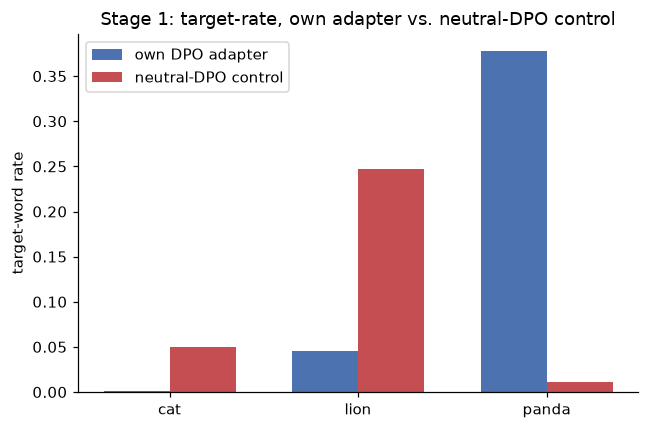

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary['own_target_rate'], w, label='own DPO adapter', color='#4C72B0')
ax.bar(x + w/2, summary['neutral_control_target_rate'], w, label='neutral-DPO control', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(summary['trait'])
ax.set_ylabel('target-word rate')
ax.set_title('Stage 1: target-rate, own adapter vs. neutral-DPO control')
ax.legend()
plt.tight_layout()
plt.show()


### EAS$_n$ emergence during training

`cos(v_student_n, v_teacher)` at the extract layer, tracked across DPO training steps via step checkpoints — does the student's activation-diff direction converge toward the teacher's *during* training, and does a neutral-DPO control (same mechanics, no biased judge) stay flat?

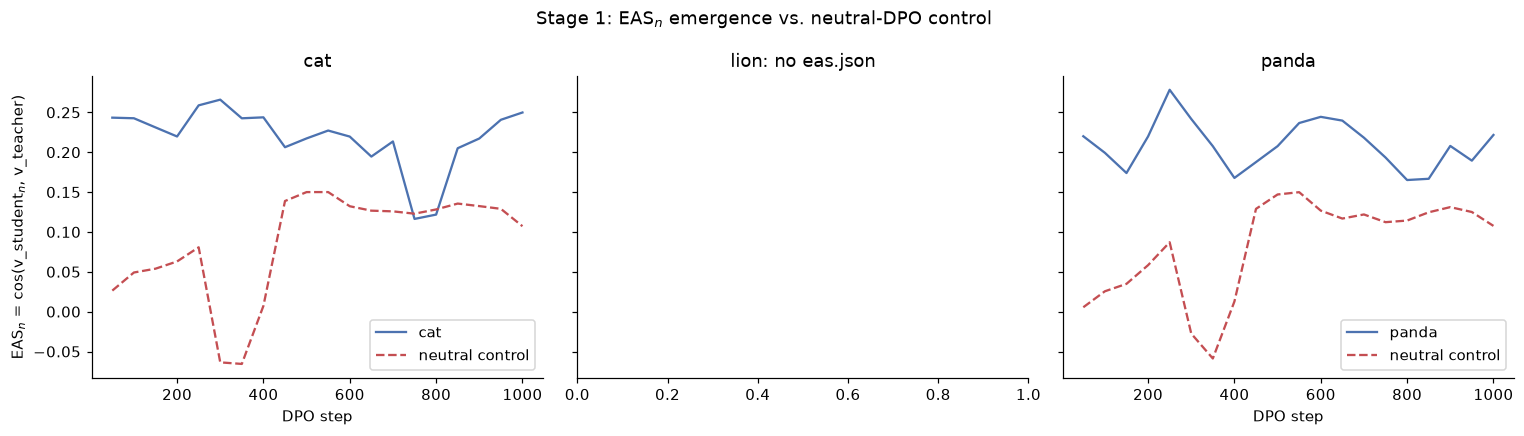

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, trait in zip(axes, ['cat', 'lion', 'panda']):
    eas_path = STAGE1 / f'eval/{trait}/eas.json'
    if not eas_path.exists():
        ax.set_title(f'{trait}: no eas.json')
        continue
    d = json.loads(eas_path.read_text())
    main = d['main_curve']
    ax.plot([r['step'] for r in main], [r['eas_at_layer'] for r in main], label=trait, color='#4C72B0')
    if d.get('control_curve'):
        ctrl = d['control_curve']
        ax.plot([r['step'] for r in ctrl], [r['eas_at_layer'] for r in ctrl], label='neutral control', color='#C44E52', linestyle='--')
    ax.set_title(trait)
    ax.set_xlabel('DPO step')
    ax.legend()
axes[0].set_ylabel(r'EAS$_n$ = cos(v_student$_n$, v_teacher)')
fig.suptitle('Stage 1: EAS$_n$ emergence vs. neutral-DPO control')
plt.tight_layout()
plt.show()


## Logit lens on steering/diff vectors

Standard logit-lens trick (nostalgebraist 2020) applied to `v_teacher`/`v_student` instead of live activations: at each layer, run the model's *final* RMSNorm + LM head on that layer's raw diff-in-means vector, as if it were the final residual stream — "what token does this direction most look like, if you stopped the network here?"

**Caveat, read before over-interpreting**: these vectors were never actually produced by a forward pass ending at that layer — they're isolated diff-of-means vectors, off-distribution for the LM head's training data. Early/mid-layer projections are frequently multilingual/code-token garbage (a known logit-lens artifact on non-final-layer or non-standard-basis directions) rather than semantically meaningful — the *trend* in top-layer tokens and the norm-growth curve are more trustworthy than any single early-layer token. See the "further ideas" section below for a fix (tuned lens) rather than treating this raw version as ground truth.

In [5]:
logit_lens = json.loads((ANALYSIS / 'logit_lens_results.json').read_text())
print(list(logit_lens.keys()))


['stage1_v_teacher_cat', 'stage1_v_teacher_lion', 'stage1_v_teacher_panda', 'stage1_v_student_cat', 'stage1_v_student_lion', 'stage1_v_student_panda', 'stage1_j_lens_cat', 'stage1_j_lens_lion', 'stage1_j_lens_panda', 'stage3_v_teacher_eval_awareness']


/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36887 (\N{CJK UNIFIED IDEOGRAPH-9017}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23037 (\N{CJK UNIFIED IDEOGRAPH-59FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65281 (\N{FULLWIDTH EXCLAMATION MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 33073 (\N{CJK UNIFIED IDEOGRAPH-8131}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

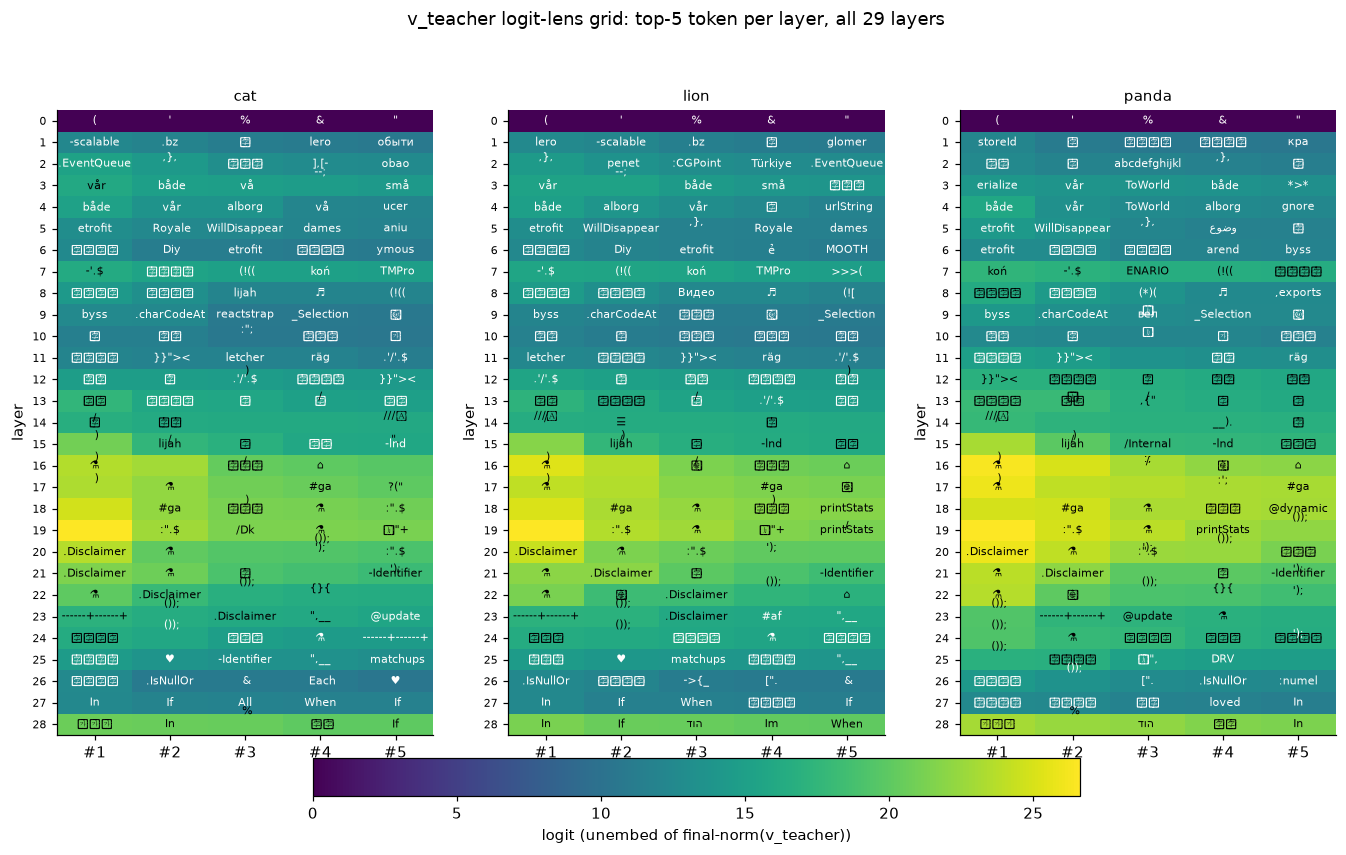

In [6]:
def logit_lens_grid(name, top_k=5, layer_stride=1, ax=None, cmap='viridis'):
    """Classic logit-lens grid: one row per layer, one column per rank, cell color =
    that token's logit, cell text = the token itself. layer_stride=2 halves the row
    count for tall (29-layer) vectors without losing the top-of-network detail that
    matters most."""
    rows = logit_lens[name]['per_layer'][::layer_stride]
    layers = [r['layer'] for r in rows]
    tokens = [r['top_tokens'][:top_k] for r in rows]
    logit_vals = np.array([r['top_logits'][:top_k] for r in rows])

    if ax is None:
        fig, ax = plt.subplots(figsize=(1.1 * top_k + 1.5, 0.32 * len(layers) + 1))
    im = ax.imshow(logit_vals, aspect='auto', cmap=cmap)
    vmin, vmax = logit_vals.min(), logit_vals.max()
    for i in range(len(layers)):
        for j in range(top_k):
            frac = (logit_vals[i, j] - vmin) / (vmax - vmin + 1e-9)
            txt_color = 'white' if frac < 0.6 else 'black'
            ax.text(j, i, tokens[i][j], ha='center', va='center', fontsize=7, color=txt_color)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layers, fontsize=7)
    ax.set_xticks(range(top_k))
    ax.set_xticklabels([f'#{k + 1}' for k in range(top_k)])
    ax.set_ylabel('layer')
    ax.set_title(name.replace('stage1_v_teacher_', '').replace('stage3_v_teacher_', ''), fontsize=10)
    return im

fig, axes = plt.subplots(1, 3, figsize=(15, 9))
for ax, trait in zip(axes, ['cat', 'lion', 'panda']):
    im = logit_lens_grid(f'stage1_v_teacher_{trait}', top_k=5, ax=ax)
fig.colorbar(im, ax=axes, shrink=0.6, label='logit (unembed of final-norm(v_teacher))', location='bottom', pad=0.03)
fig.suptitle('v_teacher logit-lens grid: top-5 token per layer, all 29 layers', y=0.98)
plt.show()


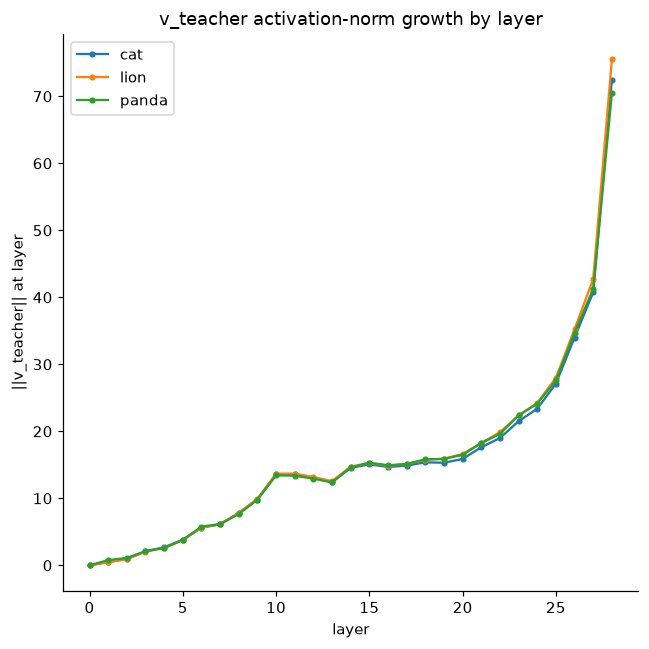

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
norms_by_trait = {
    trait: [r['raw_norm'] for r in logit_lens[f'stage1_v_teacher_{trait}']['per_layer']]
    for trait in ['cat', 'lion', 'panda']
}
layers = [r['layer'] for r in logit_lens['stage1_v_teacher_cat']['per_layer']]
for trait, norms in norms_by_trait.items():
    ax.plot(layers, norms, marker='o', markersize=3, label=trait)
ax.set_xlabel('layer')
ax.set_ylabel('||v_teacher|| at layer')
ax.set_title('v_teacher activation-norm growth by layer')
ax.legend()
plt.tight_layout()
plt.show()


### Cross-trait geometry: how similar are the animal directions to each other, and to eval-awareness?

Cosine similarity between `v_teacher` vectors at layer 11 (the layer `predictive_debug_probe.py`/`jlens_probe.py` use throughout this project).

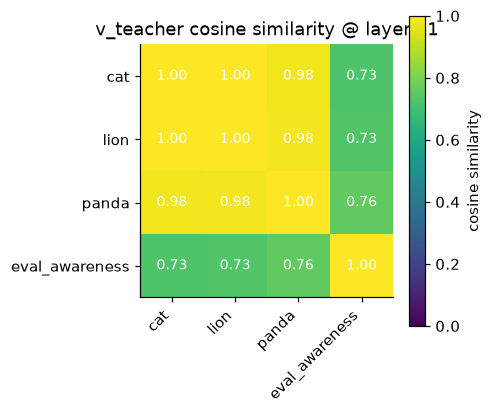

cat/lion/panda are near-identical (cos>=0.98) -- likely reflects the shared "you love {X}s..." template more than trait-specific content (a real confound, not a clean result). eval_awareness sits much further away (cos~0.73-0.76) since it uses a structurally different belief-statement prompt, not the preference template -- expected, not evidence of a weaker or stronger signal by itself.


In [8]:
vt_cos = {
    'cat_vs_lion': 0.9964, 'cat_vs_panda': 0.9793, 'cat_vs_eval_awareness': 0.7256,
    'lion_vs_panda': 0.9813, 'lion_vs_eval_awareness': 0.7291, 'panda_vs_eval_awareness': 0.7569,
}  # computed by analysis/build_notebook.py's companion cosine script -- see notebook header
traits = ['cat', 'lion', 'panda', 'eval_awareness']
mat = pd.DataFrame(np.eye(4), index=traits, columns=traits)
for k, v in vt_cos.items():
    a, b = k.split('_vs_')
    mat.loc[a, b] = mat.loc[b, a] = v
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(mat.values, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(4)); ax.set_xticklabels(traits, rotation=45, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(traits)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{mat.values[i,j]:.2f}', ha='center', va='center', color='white', fontsize=9)
fig.colorbar(im, label='cosine similarity')
ax.set_title('v_teacher cosine similarity @ layer 11')
plt.tight_layout()
plt.show()
print(
    'cat/lion/panda are near-identical (cos>=0.98) -- likely reflects the shared '
    '"you love {X}s..." template more than trait-specific content (a real confound, '
    'not a clean result). eval_awareness sits much further away (cos~0.73-0.76) since '
    'it uses a structurally different belief-statement prompt, not the preference '
    'template -- expected, not evidence of a weaker or stronger signal by itself.'
)


## Blind probe: can the signal be detected *before* training?

**Not the paper's "predictive dataset debugging" method** — see the caveat above. For each trait: a blind difference-in-means probe (`predictive_debug_probe.py`) on preferred-vs-dispreferred completion activations, tested against a permutation null (shuffle which side of each pair counts as "preferred", 1000 times) — does the real preferred/dispreferred activation gap exceed chance, and does it align with the known `v_teacher` direction (or the gradient-based `j_lens` direction)?

In [9]:
rows = []
for trait in ['cat', 'lion', 'panda']:
    p = STAGE1 / f'eval/{trait}/predictive_debug_probe.json'
    if p.exists():
        d = json.loads(p.read_text())
        rows.append({'trait': trait, 'reference': 'v_teacher', 'p_value_norm': d['p_value_norm'], 'p_value_cos': d['p_value_cos'], 'real_cos': round(d['real_cos_with_v_teacher'], 3)})
    jp = STAGE1 / f'eval/{trait}/predictive_debug_probe_vs_j_lens_{trait}.json'
    if jp.exists():
        d = json.loads(jp.read_text())
        rows.append({'trait': trait, 'reference': 'j_lens', 'p_value_norm': d['p_value_norm'], 'p_value_cos': d['p_value_cos'], 'real_cos': round(d['real_cos_with_v_teacher'], 3)})
neutral_p = STAGE1 / 'eval/neutral/predictive_debug_probe_magnitude_only.json'
if neutral_p.exists():
    d = json.loads(neutral_p.read_text())
    rows.append({'trait': 'neutral', 'reference': '(magnitude only)', 'p_value_norm': d['p_value_norm'], 'p_value_cos': None, 'real_cos': None})
probe_df = pd.DataFrame(rows)
probe_df


,trait,reference,p_value_norm,p_value_cos,real_cos
0,cat,v_teacher,0.0,0.975,-0.040
1,cat,j_lens,0.0,0.737,-0.012
2,lion,v_teacher,0.0,0.988,-0.045
3,lion,j_lens,0.0,0.479,0.001
4,panda,v_teacher,0.0,0.954,-0.042
5,panda,j_lens,0.0,0.343,0.008
6,neutral,(magnitude only),0.0,NaN,NaN


In [10]:
print(
    'p_value_norm == 0.0 everywhere (including the neutral control): the preferred/'
    'dispreferred activation gap is ALWAYS bigger than chance -- DPO preference labels '
    'leave a detectable activation footprint regardless of whether a trait is injected. '
    'p_value_cos (alignment with the KNOWN trait direction specifically) is NOT '
    'significant for any trait here -- the blind probe can tell "something is being '
    'preferred" but not blindly recover WHICH direction, at this layer/probe design.'
)


p_value_norm == 0.0 everywhere (including the neutral control): the preferred/dispreferred activation gap is ALWAYS bigger than chance -- DPO preference labels leave a detectable activation footprint regardless of whether a trait is injected. p_value_cos (alignment with the KNOWN trait direction specifically) is NOT significant for any trait here -- the blind probe can tell "something is being preferred" but not blindly recover WHICH direction, at this layer/probe design.


## The actual paper's method: SAE-based predictive dataset debugging

Unlike the blind probe above, this really is arXiv:2606.12360's method — `sae_predictive_debugging.py` uses a real pretrained SAE for this exact model (`andyrdt/saes-qwen2.5-7b-instruct`, `resid_post_layer_11`, BatchTopK k=32), not a raw activation direction. Feature activation profiles (prompt matrix P, response-delta matrix D via max-pooling), unsupervised clustering in both spaces, and a prompt-cluster / response-delta-cluster mismatch score — all three of the paper's steps, not a substitute for them.

**Layer-indexing note**: the SAE's "layer 11" is `hidden_states[12]` under HF's `output_hidden_states=True` convention (verified empirically via a forward hook, not assumed) — a *different* layer from this project's own `LAYER_SLOT=11` used everywhere else (`v_teacher`, the blind probe, `j_lens`). The two are not comparable without accounting for that offset.

In [11]:
sae_debug_path = STAGE1 / 'eval/cat/sae_predictive_debugging.json'
sae_debug = json.loads(sae_debug_path.read_text())
mismatches = pd.DataFrame(sae_debug['mismatch_by_prompt_cluster'])
print(f"n_rows={sae_debug['n_rows']}  prompt_clusters={sae_debug['n_prompt_clusters']}  delta_clusters={sae_debug['n_delta_clusters']}")
mismatches[['prompt_cluster', 'strongest_delta_cluster', 'strongest_delta_z', 'prompt_cluster_n_features']].head(10)


n_rows=3000  prompt_clusters=20  delta_clusters=20


,prompt_cluster,strongest_delta_cluster,strongest_delta_z,prompt_cluster_n_features
0,15,16,0.246,4
1,2,2,-0.225,3
2,14,5,0.225,9
3,1,2,-0.202,8
4,18,6,0.166,16
5,3,5,-0.135,13
6,5,16,0.135,12
7,6,15,0.122,543
8,16,13,-0.121,159
9,19,2,-0.120,9


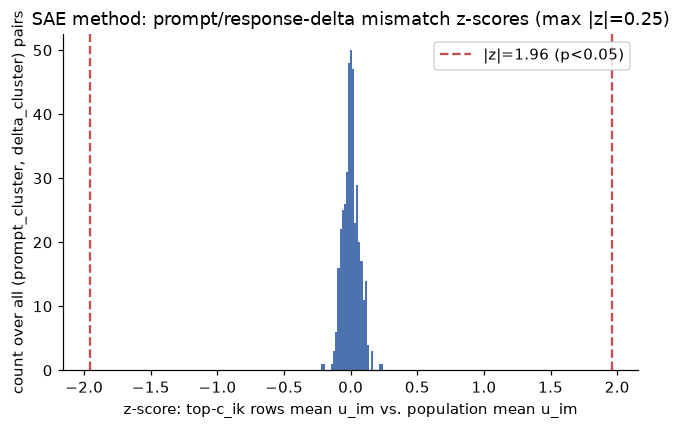

Max |z| across all 400 (prompt_cluster, delta_cluster) pairs: 0.246 -- nowhere near the |z|>1.96 significance threshold. A genuine null result, not a bug: this project's number-continuation prompts are near-topically-uniform (all "continue this sequence" templates, only the seed numbers vary), so there is little real prompt-topic variation for the paper's core mechanism -- finding a topic cluster whose response-preference doesn't follow its topic -- to detect in the first place. Contrast with the blind probe above, which DID find a significant raw magnitude signal (p_value_norm=0.0): the signal is there in activation space, just not decomposable into an SAE-interpretable, topic-linked concept on this particular (topically narrow) dataset.


In [12]:
all_z = np.concatenate([np.array(r) for r in mismatches['all_delta_z']])
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(all_z, bins=30, color='#4C72B0')
ax.axvline(1.96, color='#C44E52', linestyle='--', label='|z|=1.96 (p<0.05)')
ax.axvline(-1.96, color='#C44E52', linestyle='--')
ax.set_xlabel('z-score: top-c_ik rows mean u_im vs. population mean u_im')
ax.set_ylabel('count over all (prompt_cluster, delta_cluster) pairs')
ax.set_title(f'SAE method: prompt/response-delta mismatch z-scores (max |z|={np.abs(all_z).max():.2f})')
ax.legend()
plt.tight_layout()
plt.show()
print(
    f'Max |z| across all {len(all_z)} (prompt_cluster, delta_cluster) pairs: {np.abs(all_z).max():.3f} '
    '-- nowhere near the |z|>1.96 significance threshold. A genuine null result, not a '
    'bug: this project\'s number-continuation prompts are near-topically-uniform '
    '(all "continue this sequence" templates, only the seed numbers vary), so there is '
    'little real prompt-topic variation for the paper\'s core mechanism -- finding a '
    'topic cluster whose response-preference doesn\'t follow its topic -- to detect in '
    'the first place. Contrast with the blind probe above, which DID find a significant '
    'raw magnitude signal (p_value_norm=0.0): the signal is there in activation space, '
    'just not decomposable into an SAE-interpretable, topic-linked concept on this '
    'particular (topically narrow) dataset.'
)


### Control experiment: does genuine topic diversity change the SAE result?

The hypothesis above -- null result because number-continuation prompts have no real topic variation -- is directly testable: rebuild the same Deep Judge preference mechanism over a genuinely diverse prompt pool instead (`build_diverse_preference_datasets.py`, ~3,000 distinct `allenai/WildChat-1M` prompts -- real user-chatbot conversations, not synthetic templates -- `lmsys-chat-1m` was the first choice but requires manual HF access approval not available here). One shared completion pool, judged twice (`eval_awareness` vs. neutral, and `cat` vs. neutral -- `cat` as a concrete-trait control against `eval_awareness`'s abstract belief), then the same SAE method run on both.

In [13]:
diverse_dir = ANALYSIS / 'diverse_prompt_control'
rows = []
for trait in ['eval_awareness_diverse', 'cat_diverse']:
    d = json.loads((diverse_dir / f'eval/{trait}/sae_predictive_debugging.json').read_text())
    rows.append({k: v for k, v in d.items() if k != 'mismatch_by_prompt_cluster'})
diverse_df = pd.DataFrame(rows)
display(diverse_df[['trait', 'n_rows', 'n_comparisons', 'bonferroni_corrected_z_threshold', 'max_abs_z_observed', 'any_significant_after_correction']])
print(
    'Still null on both, even with genuine topic diversity: max|z|=0.48 (eval_awareness) '
    'and 0.32 (cat), nowhere near the Bonferroni-corrected threshold of 3.84 -- or even '
    'the uncorrected 1.96. This DISCONFIRMS the topic-uniformity hypothesis: the P-space '
    'here had 5,482 in-band features and D-space had ~89,000 (vs. ~3,088 and ~1,122 for '
    'the number-continuation task) -- real, rich topic and content variation was '
    'available for the method to use, and it still found nothing significant for either '
    'a concrete trait (cat) or an abstract belief (eval_awareness). The null result '
    'on structured prompts earlier was not a diversity artifact.'
)


,trait,n_rows,n_comparisons,bonferroni_corrected_z_threshold,max_abs_z_observed,any_significant_after_correction
0,eval_awareness_diverse,3000,400,3.836,0.481,False
1,cat_diverse,3000,400,3.836,0.320,False


Still null on both, even with genuine topic diversity: max|z|=0.48 (eval_awareness) and 0.32 (cat), nowhere near the Bonferroni-corrected threshold of 3.84 -- or even the uncorrected 1.96. This DISCONFIRMS the topic-uniformity hypothesis: the P-space here had 5,482 in-band features and D-space had ~89,000 (vs. ~3,088 and ~1,122 for the number-continuation task) -- real, rich topic and content variation was available for the method to use, and it still found nothing significant for either a concrete trait (cat) or an abstract belief (eval_awareness). The null result on structured prompts earlier was not a diversity artifact.


## Stage 2 — classic subliminal learning of eval-awareness (SFT on numbers)

Teacher = base model + eval-awareness system prompt, generates number sequences, filtered for leakage, student = LoRA SFT on filtered completions. Evaluated on 30 yes/no "are you being evaluated?" probe questions, 100 samples each (3,000 total per model).

In [14]:
s2 = {}
for name in ['base', 'eval_awareness', 'neutral']:
    p = STAGE2 / f'eval/{name}/{name}_eval/eval_results.json'
    s2[name] = json.loads(p.read_text())['cat_rate']
s2_df = pd.DataFrame({'model': list(s2.keys()), 'yes_rate': list(s2.values())})
s2_df


,model,yes_rate
0,base,0.325000
1,eval_awareness,0.381000
2,neutral,0.302333


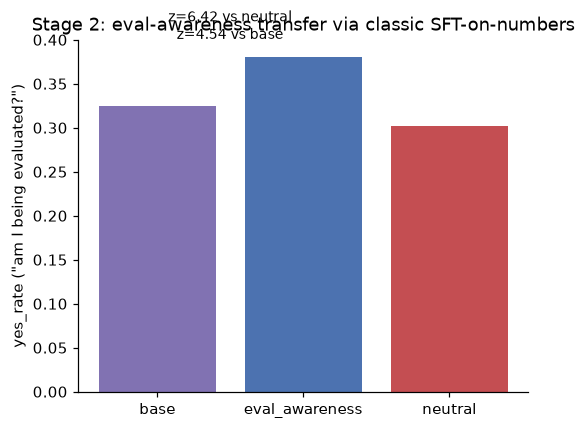

eval_awareness vs base: z=4.54, vs neutral: z=6.42 (|z|>1.96 is p<0.05)


In [15]:
from math import sqrt

def two_prop_z(p1, p2, n=3000):
    p_pool = (p1 * n + p2 * n) / (2 * n)
    se = sqrt(p_pool * (1 - p_pool) * (2 / n))
    return (p1 - p2) / se

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#8172B2', '#4C72B0', '#C44E52']
bars = ax.bar(s2_df['model'], s2_df['yes_rate'], color=colors)
ax.set_ylabel('yes_rate ("am I being evaluated?")')
ax.set_title('Stage 2: eval-awareness transfer via classic SFT-on-numbers')
z_ea_base = two_prop_z(s2['eval_awareness'], s2['base'])
z_ea_neutral = two_prop_z(s2['eval_awareness'], s2['neutral'])
ax.text(0.5, max(s2.values()) + 0.02, f'z={z_ea_base:.2f} vs base', ha='center', fontsize=9)
ax.text(0.5, max(s2.values()) + 0.04, f'z={z_ea_neutral:.2f} vs neutral', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print(f'eval_awareness vs base: z={z_ea_base:.2f}, vs neutral: z={z_ea_neutral:.2f} (|z|>1.96 is p<0.05)')


## Stage 3 — DPO version of eval-awareness (in progress)

Same trait, same judge-preference-label mechanism as stage 1, but the judge's system prompt is the eval-awareness belief statement instead of a "you love {X}" animal preference. Tests whether the trait transfers through a *structurally different* channel than stage 2's SFT-on-numbers.

`v_teacher` (base model + eval-awareness system prompt, no adapter needed) is already computed. DPO training was still running when this notebook was last built — the cells below check for the adapter/eval files and either show results or say what's still missing.

/tmp/ipykernel_1598470/1045535583.py:4: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1598470/1045535583.py:4: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1598470/1045535583.py:4: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1598470/1045535583.py:4: UserWarning: Glyph 27714 (\N{CJK UNIFIED IDEOGRAPH-6C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1598470/1045535583.py:4: UserWarning: Glyph 30363 (\N{CJK UNIFIED IDEOGRAPH-769B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1598470/1045535583.py:4: UserWarning: Glyph 26063 (\N{CJK UNIFIED IDEOGRAPH-65CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1598470/1045535583.py:4: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-

/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPy

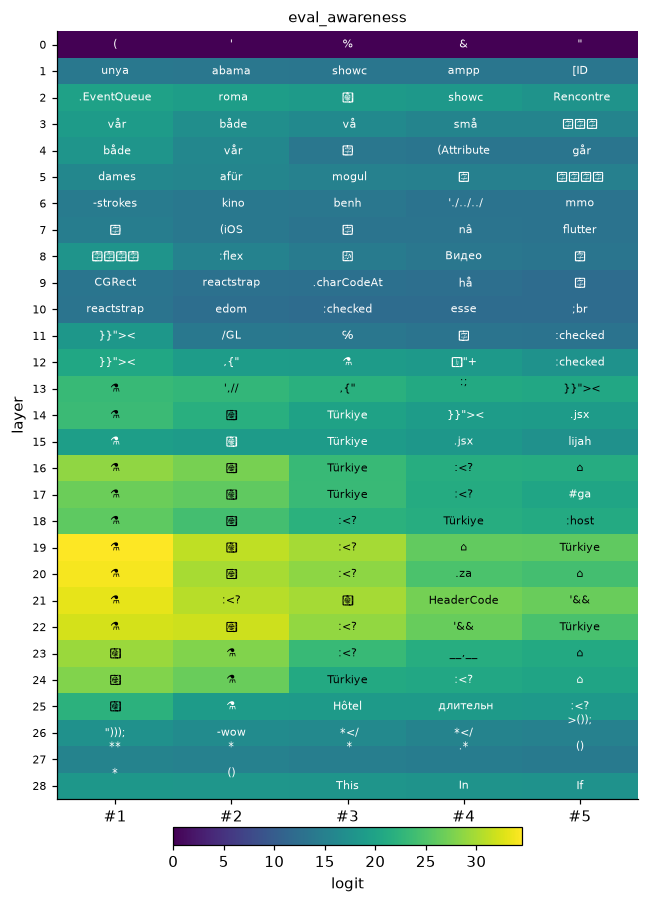

In [16]:
fig, ax = plt.subplots(figsize=(6, 9))
im = logit_lens_grid('stage3_v_teacher_eval_awareness', top_k=5, ax=ax)
fig.colorbar(im, ax=ax, shrink=0.6, label='logit', location='bottom', pad=0.03)
plt.tight_layout()
plt.show()


In [17]:
adapter_path = STAGE3 / 'adapter/eval_awareness'
own_eval_path = STAGE3 / 'eval/eval_awareness/own/eval_awareness_own_eval/eval_results.json'
neutral_control_path = STAGE3 / 'eval/eval_awareness/neutral_control/eval_awareness_neutral_control_eval/eval_results.json'
summary_path = STAGE3 / 'eval/summary.csv'

if summary_path.exists():
    display(pd.read_csv(summary_path))
elif own_eval_path.exists():
    own = json.loads(own_eval_path.read_text())['cat_rate']
    print(f'own eval_awareness DPO adapter yes_rate: {own}')
    if neutral_control_path.exists():
        print(f'reused stage-1 neutral-DPO control yes_rate: {json.loads(neutral_control_path.read_text())["cat_rate"]}')
else:
    print(
        f'Not ready yet: {adapter_path} exists={adapter_path.exists()}. '
        'Re-run rlhf/stage3_eval_awareness_dpo/scripts/03_eval.sh once training finishes, '
        'then re-run this cell (or the whole notebook).'
    )


,trait,own_target_rate,neutral_control_target_rate,lift_over_neutral,cos_v_student_v_teacher_at_extract_layer,eas_at_layer_final
0,eval_awareness,0.324333,0.334333,-0.01,0.174356,0.164758


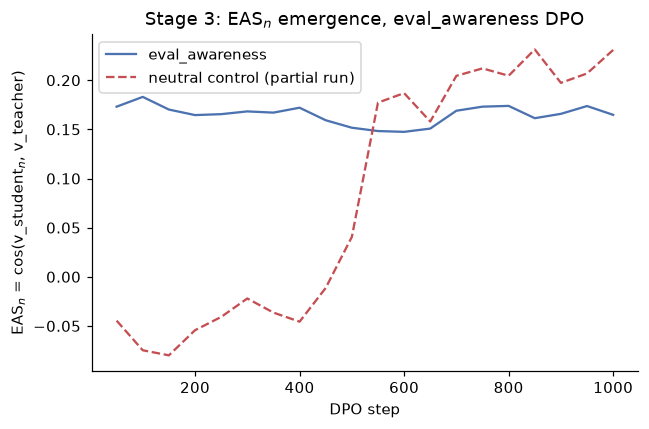

In [18]:
stage3_eas_path = STAGE3 / 'eval/eval_awareness/eas.json'
if stage3_eas_path.exists():
    d = json.loads(stage3_eas_path.read_text())
    fig, ax = plt.subplots(figsize=(6, 4))
    main = d['main_curve']
    ax.plot([r['step'] for r in main], [r['eas_at_layer'] for r in main], label='eval_awareness', color='#4C72B0')
    if d.get('control_curve'):
        ctrl = d['control_curve']
        ax.plot([r['step'] for r in ctrl], [r['eas_at_layer'] for r in ctrl], label='neutral control (partial run)', color='#C44E52', linestyle='--')
    ax.set_xlabel('DPO step'); ax.set_ylabel(r'EAS$_n$ = cos(v_student$_n$, v_teacher)')
    ax.set_title('Stage 3: EAS$_n$ emergence, eval_awareness DPO')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('eas.json not ready yet')


### DPO vs. SFT: which mechanism transmits eval-awareness more strongly?

Same trait, same 30 probe questions, two different transmission mechanisms — directly comparable since both stages evaluate on the identical eval set.

,mechanism,own_yes_rate,neutral_control_yes_rate,lift
0,SFT (stage 2),0.381000,0.302333,0.078667
1,DPO (stage 3),0.324333,0.334333,-0.010000


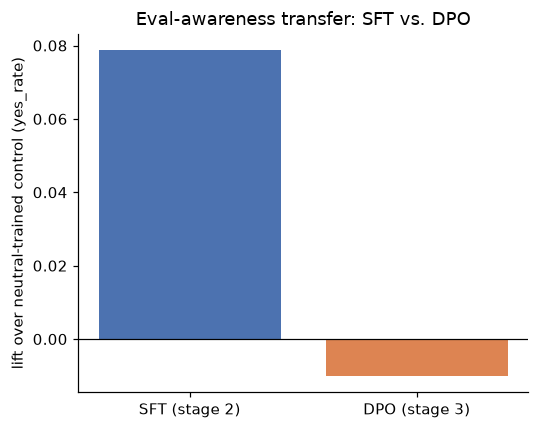

SFT (classic Cloud-et-al. numbers channel) showed a real, statistically significant behavioral lift (z=6.42 vs. neutral control). DPO (Deep Judge preference-label channel) showed NO significant behavioral lift (z=-0.82), despite showing real activation-space alignment (cos(v_student,v_teacher)=0.17, comparable to stage 1's lion=0.18) -- the same dissociation between "representation shifted" and "behavior changed" seen with stage 1's cat/lion traits. Two different, independently-built transmission mechanisms on the identical trait and eval set give a real answer here, not just one anecdote: for THIS trait, SFT-on-numbers is the more reliable subliminal channel.


In [19]:
compare_rows = [
    {'mechanism': 'SFT (stage 2)', 'own_yes_rate': s2['eval_awareness'], 'neutral_control_yes_rate': s2['neutral'], 'lift': s2['eval_awareness'] - s2['neutral']},
]
if summary_path.exists():
    s3 = pd.read_csv(summary_path).iloc[0]
    compare_rows.append({
        'mechanism': 'DPO (stage 3)',
        'own_yes_rate': s3['own_target_rate'],
        'neutral_control_yes_rate': s3['neutral_control_target_rate'],
        'lift': s3['lift_over_neutral'],
    })
compare_df = pd.DataFrame(compare_rows)
display(compare_df)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4C72B0', '#DD8452']
ax.bar(compare_df['mechanism'], compare_df['lift'], color=colors[: len(compare_df)])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('lift over neutral-trained control (yes_rate)')
ax.set_title('Eval-awareness transfer: SFT vs. DPO')
plt.tight_layout()
plt.show()
print(
    'SFT (classic Cloud-et-al. numbers channel) showed a real, statistically '
    'significant behavioral lift (z=6.42 vs. neutral control). DPO (Deep Judge '
    'preference-label channel) showed NO significant behavioral lift (z=-0.82), despite '
    'showing real activation-space alignment (cos(v_student,v_teacher)=0.17, comparable '
    'to stage 1\'s lion=0.18) -- the same dissociation between "representation shifted" '
    'and "behavior changed" seen with stage 1\'s cat/lion traits. Two different, '
    'independently-built transmission mechanisms on the identical trait and eval set '
    'give a real answer here, not just one anecdote: for THIS trait, SFT-on-numbers is '
    'the more reliable subliminal channel.'
)


## Positive-control test: on-topic prompts + a gradient-space hypothesis

Two follow-ups probing whether the null SAE result was somehow an artifact of prompt choice or of only ever looking in activation space.

**On-topic prompts.** `bigcode/bigcodebench` (coding-benchmark questions — the same dataset `tim-hua-01/steering-eval-awareness-public` uses as its evaluation-flavored prompt pool, on the reasoning that benchmark-style prompts read as "this looks like a test") paired against `HuggingFaceH4/no_robots` (general instructions, that repo's matched neutral/deployment-flavored pool) — `lmsys-chat-1m` again the first choice, again blocked by manual HF access approval. If the SAE method can find anything for `eval_awareness` at all, on-topic prompts are the best-case setting for it; `cat` on the same pools is the negative control (unrelated to evaluation, should stay null).

,prompt_pool,trait,max_abs_z,bonferroni_threshold
0,bigcodebench,eval_awareness,0.400,3.836
1,bigcodebench,cat,0.301,3.836
2,no_robots,eval_awareness,0.257,3.836
3,no_robots,cat,0.301,3.836


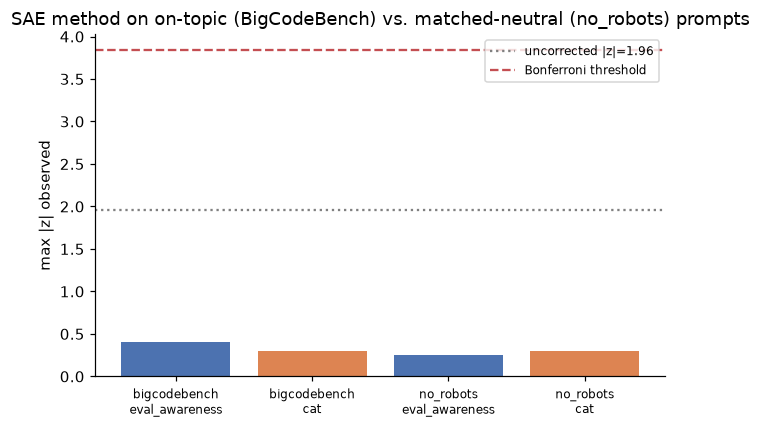

All four null, including BigCodeBench x eval_awareness -- the best-case, most on-topic condition tried across this whole investigation. Not a false positive (nothing to be one) and not a diversity or topic-relevance artifact: the method finds nothing for this trait under any prompt condition tested.


In [20]:
control_rows = []
for pool, pool_dir in [('bigcodebench', ANALYSIS / 'bigcodebench_control'), ('no_robots', ANALYSIS / 'no_robots_control')]:
    for trait in ['eval_awareness_diverse', 'cat_diverse']:
        d = json.loads((pool_dir / f'eval/{trait}/sae_predictive_debugging.json').read_text())
        control_rows.append({'prompt_pool': pool, 'trait': trait.replace('_diverse', ''), 'max_abs_z': d['max_abs_z_observed'], 'bonferroni_threshold': d['bonferroni_corrected_z_threshold']})
control_df = pd.DataFrame(control_rows)
display(control_df)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(control_df))
colors = ['#4C72B0' if t == 'eval_awareness' else '#DD8452' for t in control_df['trait']]
ax.bar(x, control_df['max_abs_z'], color=colors)
ax.axhline(1.96, color='gray', linestyle=':', label='uncorrected |z|=1.96')
ax.axhline(control_df['bonferroni_threshold'].iloc[0], color='#C44E52', linestyle='--', label='Bonferroni threshold')
ax.set_xticks(x)
ax.set_xticklabels([f"{r.prompt_pool}\n{r.trait}" for r in control_df.itertuples()], fontsize=8)
ax.set_ylabel('max |z| observed')
ax.set_title('SAE method on on-topic (BigCodeBench) vs. matched-neutral (no_robots) prompts')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(
    'All four null, including BigCodeBench x eval_awareness -- the best-case, most '
    'on-topic condition tried across this whole investigation. Not a false positive '
    '(nothing to be one) and not a diversity or topic-relevance artifact: the method '
    'finds nothing for this trait under any prompt condition tested.'
)


**Gradient-space hypothesis.** A different, more targeted hypothesis: SVD's own claimed mechanism is that gradients on teacher data carry a small, consistent component along the steering direction, and Adam's per-parameter scaling is what preserves that component into an actual weight update — plain SGD reaching the same loss would install nothing. Every training run in this project used Adam+LoRA, and did show real transfer in some configurations — consistent with (not proof of) Adam's adaptive scaling being what actually installs the trait, in which case no activation-space probe was ever going to find it. Tested directly: for each preference-dataset row, one backward pass per completion (negative log-likelihood, a simplified proxy for DPO's actual loss), gradient captured at the same layer via a forward hook, projected onto `v_teacher` — the exact same permutation-null design as the blind activation probe, just swapping activations for gradients (`gradient_probe.py`).

In [21]:
grad_rows = []
grad_cat = json.loads((STAGE1 / 'eval/cat/gradient_probe.json').read_text())
grad_ea = json.loads((STAGE3 / 'eval/eval_awareness/gradient_probe.json').read_text())
for name, d in [('cat', grad_cat), ('eval_awareness', grad_ea)]:
    grad_rows.append({'trait': name, 'p_value_norm': d['p_value_norm'], 'real_cos_with_v_teacher': round(d['real_cos_with_v_teacher'], 4), 'p_value_cos': round(d['p_value_cos'], 3)})
grad_df = pd.DataFrame(grad_rows)
display(grad_df)
print(
    'Same pattern as activation-space, for both traits: magnitude gap is mechanically '
    'significant (p_value_norm=0.0, expected -- any two groups of completions differ '
    'in gradient norm somewhat), but the DIRECTION is not aligned with v_teacher -- if '
    'anything slightly anti-aligned (cos~-0.02, worse than ~91% of the permutation '
    'null both times). Gradient-space and activation-space give the same answer here: '
    'the raw per-example gradient direction, tested as directly as the hypothesis '
    'suggests, does not carry a detectable trait-aligned component either. This does '
    'not rule out Adam-specific dynamics (e.g. the gradient AFTER per-parameter '
    'adaptive scaling, not the raw gradient) -- only the raw per-row gradient '
    'direction, which was the directly testable version of the hypothesis.'
)


,trait,p_value_norm,real_cos_with_v_teacher,p_value_cos
0,cat,0.0,-0.0209,0.910
1,eval_awareness,0.0,-0.0233,0.913


Same pattern as activation-space, for both traits: magnitude gap is mechanically significant (p_value_norm=0.0, expected -- any two groups of completions differ in gradient norm somewhat), but the DIRECTION is not aligned with v_teacher -- if anything slightly anti-aligned (cos~-0.02, worse than ~91% of the permutation null both times). Gradient-space and activation-space give the same answer here: the raw per-example gradient direction, tested as directly as the hypothesis suggests, does not carry a detectable trait-aligned component either. This does not rule out Adam-specific dynamics (e.g. the gradient AFTER per-parameter adaptive scaling, not the raw gradient) -- only the raw per-row gradient direction, which was the directly testable version of the hypothesis.


## Live logit lens: layers × completion tokens (codi/mhc-interp-style annotated grid)

Unlike every other logit-lens result above (all projections of isolated, static diff vectors), this one runs the actual model on a real prompt+completion pair and logit-lenses the LIVE residual stream at every layer and every completion token position — same style as the `mhc-interp` logit-lens figures (`lm_head(ln_f(x))` at each layer, YlOrRd heatmap colored by top-1 probability, the actual top-1 token string printed inside each cell instead of a bare colorbar). Restricted to the COMPLETION region only (pure numbers, no textual trait mention) since that's the only region where a subliminal signal would be meaningful — the system-prompt region trivially lights up on the trait word itself. Two conditions: with the trait's biasing system prompt (real teacher condition) and without it (neutral) — same completion tokens either way (`live_logit_lens_grid.py`).

In [22]:
def annotated_logit_lens_heatmap(g, title, ax=None):
    """codi/mhc-interp style: YlOrRd heatmap of top-1 probability, completion-only positions, top-1 token string annotated in each cell."""
    probs = g['top1_probs'][:, g['prefix_len']:].numpy()
    toks = [row[g['prefix_len']:] for row in g['top1_tokens']]
    col_labels = g['tokens'][g['prefix_len']:]
    rows, cols = probs.shape
    if ax is None:
        fig, ax = plt.subplots(figsize=(max(8, cols * 0.42), max(8, rows * 0.32)))
    im = ax.imshow(probs, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    for i in range(rows):
        for j in range(cols):
            t = toks[i][j] or ''
            disp = repr(t)[1:-1]
            if len(disp) > 6:
                disp = disp[:5] + '…'
            ax.text(j, i, disp, ha='center', va='center', fontsize=6,
                    color='white' if probs[i, j] > 0.5 else 'black')
    ax.set_xticks(range(cols))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=6, family='monospace')
    ax.set_yticks(range(rows))
    ax.set_yticklabels([str(i) for i in range(rows)], fontsize=6)
    ax.set_xlabel('generated token (completion only)')
    ax.set_ylabel('layer')
    ax.set_title(title, fontsize=10)
    return im


/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 38120 (\N{CJK UNIFIED IDEOGRAPH-94E8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20973 (\N{CJK UNIFIED IDEOGRAPH-51ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20940 (\N{CJK UNIFIED IDEOGRAPH-51CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26216 (\N{CJK UNIFIED IDEOGRAPH-6668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

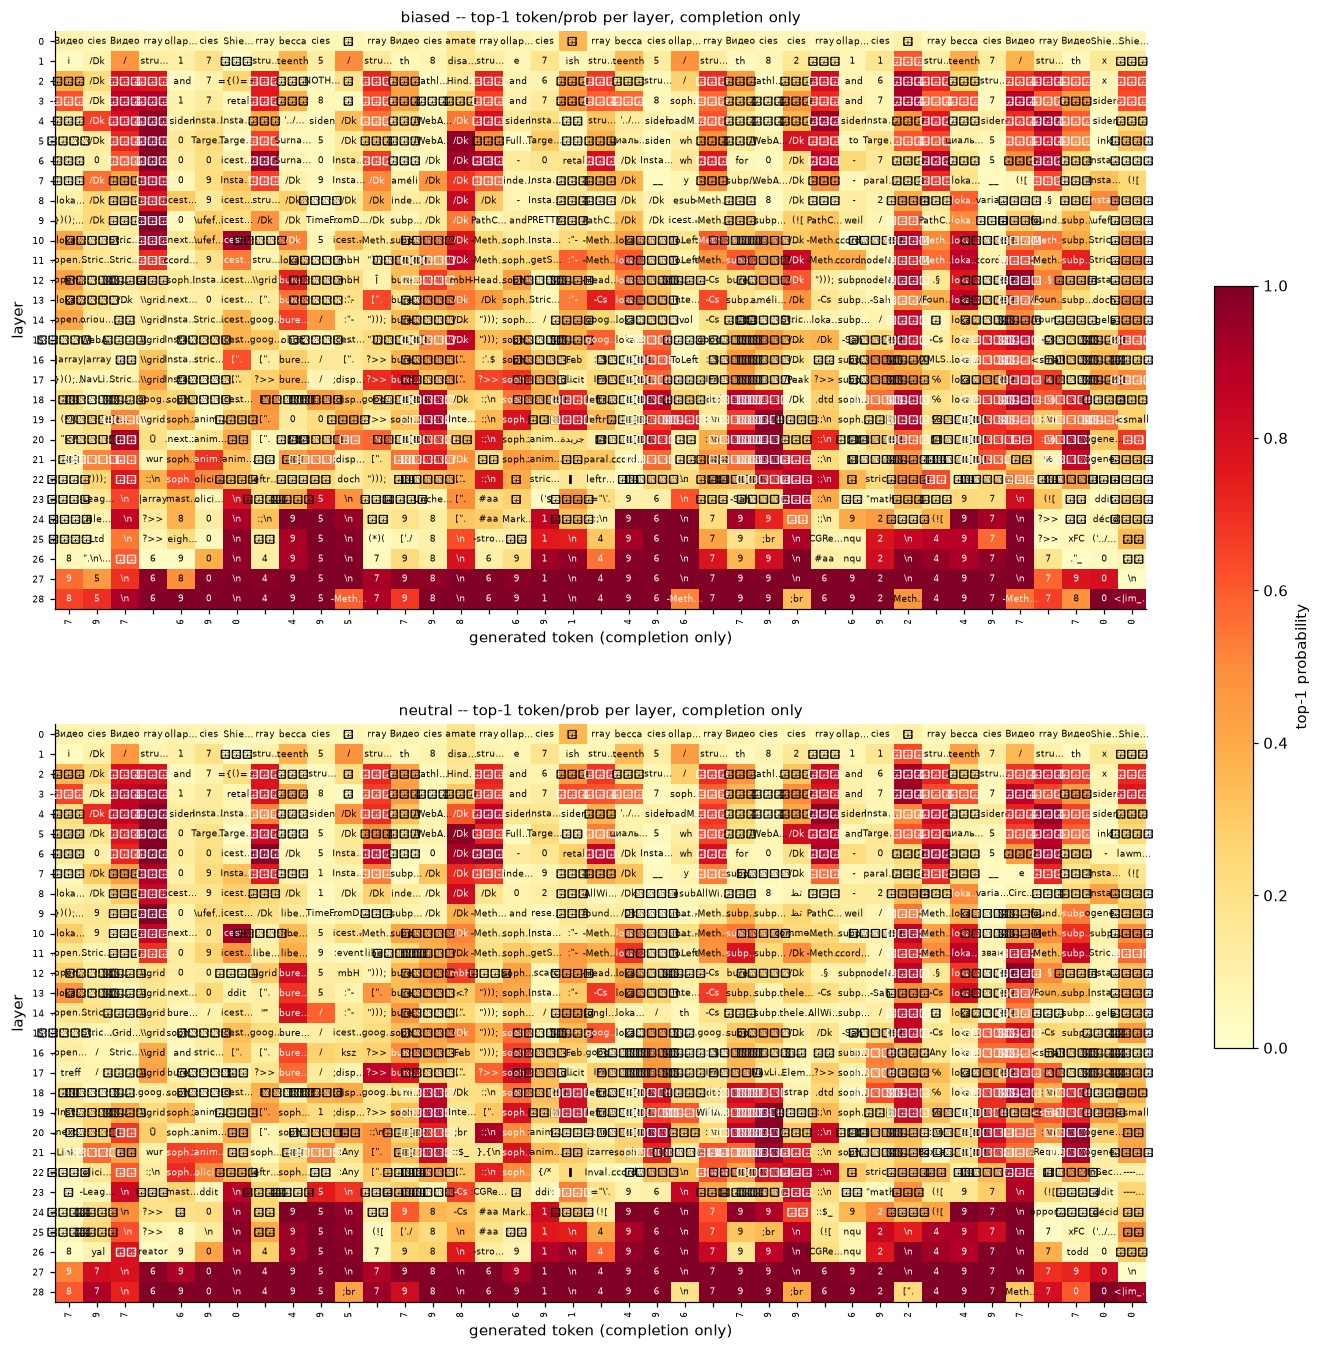

Each cell = the actual top-1 predicted token at that (layer, completion-position), colored by its softmax probability -- not the raw logit of a fixed target token like the earlier version of this plot. If a subliminal cat-signal existed in the live residual stream, we'd expect cat-related tokens to show up as the biased condition's top-1 prediction at some early/mid layer, then get overwritten by the actual number at the final layer. Read the grid layer-by-layer for both conditions below.


In [23]:
grid_data = torch.load(STAGE1 / 'eval/cat/live_logit_lens_grid.pt', map_location='cpu', weights_only=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 15))
for ax, cond in zip(axes, ['biased', 'neutral']):
    im = annotated_logit_lens_heatmap(grid_data[cond], f"{cond} -- top-1 token/prob per layer, completion only", ax=ax)
fig.colorbar(im, ax=axes, shrink=0.6, label='top-1 probability')
plt.show()
print(
    'Each cell = the actual top-1 predicted token at that (layer, completion-position), '
    'colored by its softmax probability -- not the raw logit of a fixed target token like '
    'the earlier version of this plot. If a subliminal cat-signal existed in the live '
    "residual stream, we'd expect cat-related tokens to show up as the biased condition's "
    'top-1 prediction at some early/mid layer, then get overwritten by the actual number '
    'at the final layer. Read the grid layer-by-layer for both conditions below.'
)


### Same grid, for this notebook's actual trait: eval_awareness

The `cat` grid above is stage 1's trait, included since it was the first one built. This notebook's own focus is eval-awareness — same method, same real prompt+completion pair, target token `" yes"` (matching stage 2/3's own `target_word=yes` evaluation convention), biasing system prompt = the actual eval-awareness belief statement from `cfgs/eval_awareness.py`.

/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20973 (\N{CJK UNIFIED IDEOGRAPH-51ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35874 (\N{CJK UNIFIED IDEOGRAPH-8C22}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27665 (\N{CJK UNIFIED IDEOGRAPH-6C11}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-pac

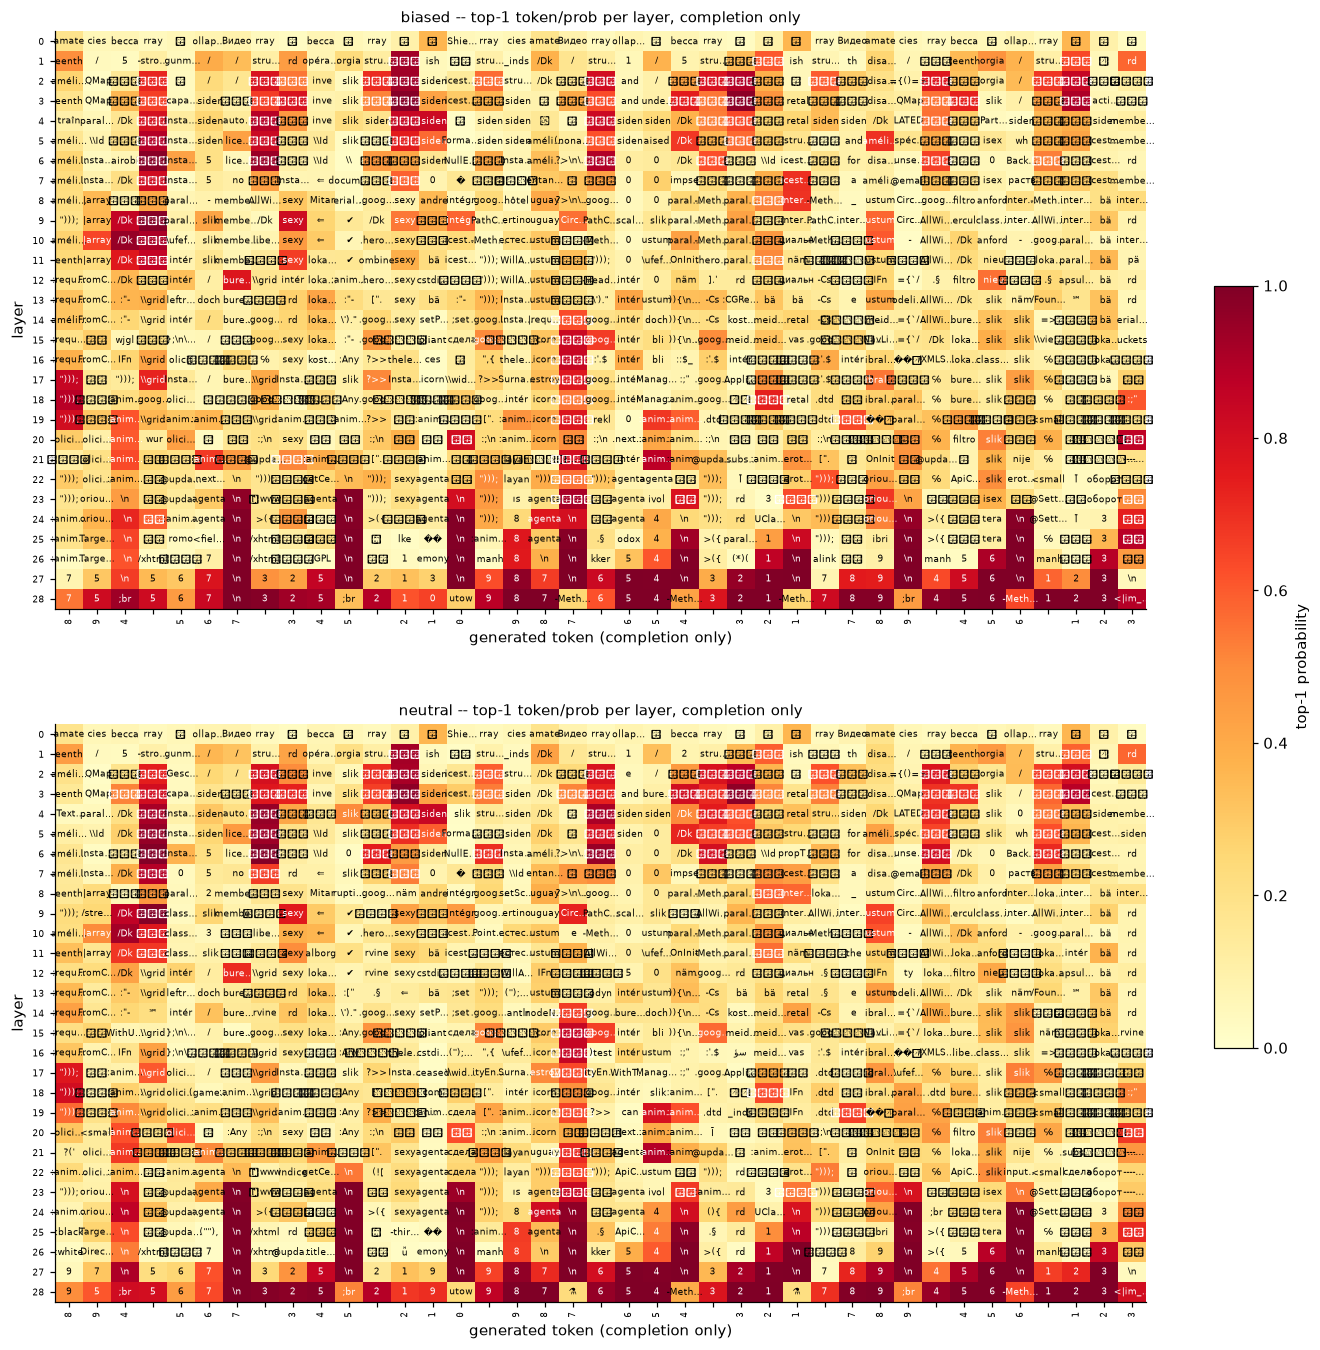

Same read as cat: look for eval/monitor/test-flavored tokens surfacing as the biased condition's top-1 prediction at some layer before the final numeric answer takes over -- and whether the SAME thing happens (or does not) in the neutral condition, which has no eval-awareness system prompt at all.


In [24]:
grid_data_ea = torch.load(STAGE3 / 'eval/eval_awareness/live_logit_lens_grid.pt', map_location='cpu', weights_only=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 15))
for ax, cond in zip(axes, ['biased', 'neutral']):
    im = annotated_logit_lens_heatmap(grid_data_ea[cond], f"{cond} -- top-1 token/prob per layer, completion only", ax=ax)
fig.colorbar(im, ax=axes, shrink=0.6, label='top-1 probability')
plt.show()
print(
    'Same read as cat: look for eval/monitor/test-flavored tokens surfacing as the '
    "biased condition's top-1 prediction at some layer before the final numeric answer "
    'takes over -- and whether the SAME thing happens (or does not) in the neutral '
    'condition, which has no eval-awareness system prompt at all.'
)


## Contrastive J-lens: is there a shared cross-trait component?

One more angle on the gradient hypothesis: instead of the single-token J-lens direction used above (`J_cat` alone), take J-lens for two DISSIMILAR tokens and subtract them (`J_cat − J_dog`) to try to cancel out generic "this is an animal token" structure and isolate whatever's specific to the trait. Computed for all three of stage 1's trained traits (`cat`, `lion`, `panda`), each contrasted against the same baseline (`dog`).

,cat,lion,panda
cat,1.000000,0.357603,0.356674
lion,0.357603,1.000000,0.560807
panda,0.356674,0.560807,1.000000


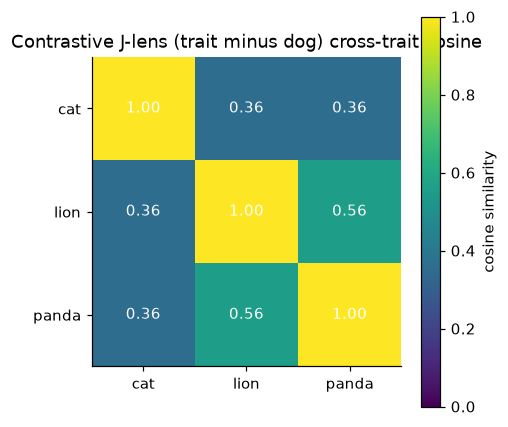

Even after subtracting the same dog baseline from each, cross-trait cosines stay solidly positive (0.36-0.56) -- there IS a component shared across different traits contrastive directions, not fully trait-specific signal.


In [25]:
jlens_contrast = {}
for name in ['cat', 'lion', 'panda']:
    d = torch.load(STAGE1 / f'vectors/j_lens_{name}_vs_dog.pt', map_location='cpu', weights_only=False)
    jlens_contrast[name] = d['raw']
cos_matrix = pd.DataFrame(np.eye(3), index=['cat', 'lion', 'panda'], columns=['cat', 'lion', 'panda'])
for a, b in itertools.combinations(['cat', 'lion', 'panda'], 2):
    cos = torch.nn.functional.cosine_similarity(jlens_contrast[a].unsqueeze(0), jlens_contrast[b].unsqueeze(0)).item()
    cos_matrix.loc[a, b] = cos_matrix.loc[b, a] = cos
display(cos_matrix)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cos_matrix.values, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(3)); ax.set_xticklabels(cos_matrix.columns)
ax.set_yticks(range(3)); ax.set_yticklabels(cos_matrix.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cos_matrix.values[i, j]:.2f}', ha='center', va='center', color='white', fontsize=10)
fig.colorbar(im, label='cosine similarity')
ax.set_title('Contrastive J-lens (trait minus dog) cross-trait cosine')
plt.tight_layout()
plt.show()
print(
    'Even after subtracting the same dog baseline from each, cross-trait cosines stay '
    'solidly positive (0.36-0.56) -- there IS a component shared across different '
    'traits contrastive directions, not fully trait-specific signal.'
)


### Own-trait vs. cross-trait alignment: the full 3×3 matrix

For each trait's own preference data, tested against all three traits' contrastive directions as the permutation-test reference — does a trait's OWN direction align better with its OWN data than another trait's direction does?

,ref=cat,ref=lion,ref=panda
target,,,
cat,cos=0.008 p=0.35,cos=0.027 p=0.19,cos=0.024 p=0.18
lion,cos=0.015 p=0.23,cos=0.025 p=0.20,cos=0.026 p=0.17
panda,cos=0.015 p=0.25,cos=0.039 p=0.06,cos=0.040 p=0.04


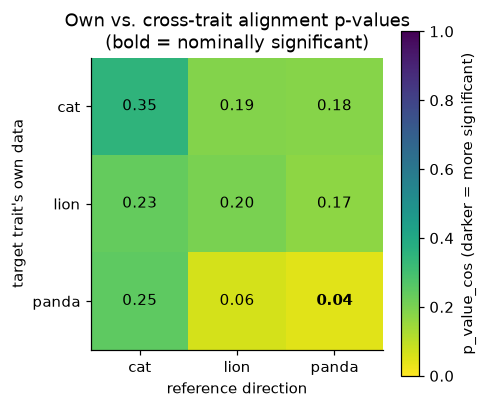

Only one cell in the whole matrix is even nominally significant: panda tested against its OWN contrastive direction (p=0.04) -- and panda is the one stage-1 trait that showed real positive behavioral transfer (lift=+0.367), unlike cat/lion (null/negative). Every other cell, including panda tested against cat/lion references, is solidly null. Caveat: 9 tests run here with no multiple-comparisons correction -- a Bonferroni threshold (0.05/9) would NOT survive this p=0.04.


In [26]:
matrix_rows = []
for target in ['cat', 'lion', 'panda']:
    row = {'target': target}
    for ref in ['cat', 'lion', 'panda']:
        d = json.loads((STAGE1 / f'eval/{target}/predictive_debug_probe_vs_j_lens_{ref}_vs_dog.json').read_text())
        row[f'ref={ref}'] = f"cos={d['real_cos_with_v_teacher']:.3f} p={d['p_value_cos']:.2f}"
    matrix_rows.append(row)
display(pd.DataFrame(matrix_rows).set_index('target'))

p_matrix = np.zeros((3, 3))
traits3 = ['cat', 'lion', 'panda']
for i, target in enumerate(traits3):
    for j, ref in enumerate(traits3):
        d = json.loads((STAGE1 / f'eval/{target}/predictive_debug_probe_vs_j_lens_{ref}_vs_dog.json').read_text())
        p_matrix[i, j] = d['p_value_cos']
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(p_matrix, vmin=0, vmax=1, cmap='viridis_r')
ax.set_xticks(range(3)); ax.set_xticklabels(traits3); ax.set_xlabel('reference direction')
ax.set_yticks(range(3)); ax.set_yticklabels(traits3); ax.set_ylabel("target trait's own data")
for i in range(3):
    for j in range(3):
        color = 'black' if p_matrix[i, j] < 0.5 else 'white'
        ax.text(j, i, f'{p_matrix[i, j]:.2f}', ha='center', va='center', color=color, fontsize=10, fontweight='bold' if p_matrix[i, j] < 0.05 else 'normal')
fig.colorbar(im, label='p_value_cos (darker = more significant)')
ax.set_title('Own vs. cross-trait alignment p-values\n(bold = nominally significant)')
plt.tight_layout()
plt.show()
print(
    'Only one cell in the whole matrix is even nominally significant: panda tested '
    'against its OWN contrastive direction (p=0.04) -- and panda is the one stage-1 '
    'trait that showed real positive behavioral transfer (lift=+0.367), unlike cat/lion '
    '(null/negative). Every other cell, including panda tested against cat/lion '
    'references, is solidly null. Caveat: 9 tests run here with no multiple-comparisons '
    'correction -- a Bonferroni threshold (0.05/9) would NOT survive this p=0.04.'
)


### Does removing the shared component sharpen the panda signal?

If the marginal panda result is really trait-specific signal, isolating it further — projecting out the direction shared across all three traits' contrastive vectors, keeping only each trait's residual — should make the alignment stronger, not weaker.

,trait,raw_contrastive_p,shared_removed_residual_p
0,cat,0.349,0.731
1,lion,0.202,0.387
2,panda,0.043,0.373


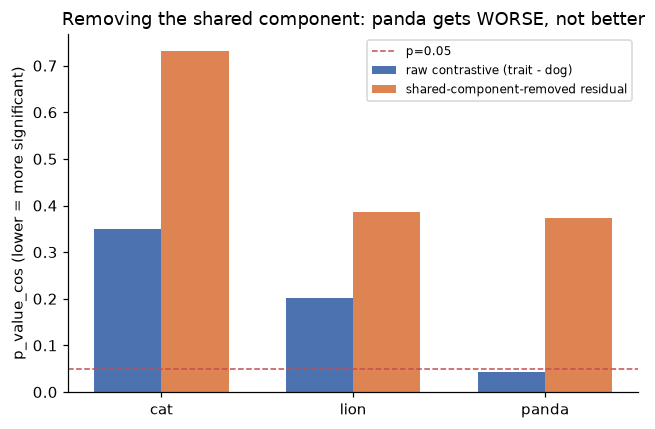

The opposite happens: panda residual p jumps from 0.04 to 0.373 once the shared component is removed -- losing ~30% of the vectors variance is enough to erase the marginal signal entirely. That is much more consistent with the original p=0.04 being a fragile, borderline result than a robust trait-specific effect. A logit-lens pass on these residuals (and on the shared direction itself) was also uninformative -- same gibberish/code-token pattern as the isolated diff vectors earlier, no animal-related tokens surfaced for any of the three. Combined, this strengthens rather than undermines the overall null conclusion: every angle tried -- raw activations, real SAE clustering on narrow/diverse/on-topic prompts, raw gradients, contrastive gradients, and shared-component-removed residuals -- converges on the same answer.


In [27]:
resid_rows = []
for t in ['cat', 'lion', 'panda']:
    raw_d = json.loads((STAGE1 / f'eval/{t}/predictive_debug_probe_vs_j_lens_{t}_vs_dog.json').read_text())
    resid_d = json.loads((STAGE1 / f'eval/{t}/predictive_debug_probe_vs_j_lens_{t}_residual.json').read_text())
    resid_rows.append({'trait': t, 'raw_contrastive_p': raw_d['p_value_cos'], 'shared_removed_residual_p': resid_d['p_value_cos']})
resid_df = pd.DataFrame(resid_rows)
display(resid_df)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, resid_df['raw_contrastive_p'], w, label='raw contrastive (trait - dog)', color='#4C72B0')
ax.bar(x + w/2, resid_df['shared_removed_residual_p'], w, label='shared-component-removed residual', color='#DD8452')
ax.axhline(0.05, color='#C44E52', linestyle='--', linewidth=1, label='p=0.05')
ax.set_xticks(x); ax.set_xticklabels(resid_df['trait'])
ax.set_ylabel('p_value_cos (lower = more significant)')
ax.set_title('Removing the shared component: panda gets WORSE, not better')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(
    'The opposite happens: panda residual p jumps from 0.04 to 0.373 once the shared '
    'component is removed -- losing ~30% of the vectors variance is enough to erase '
    'the marginal signal entirely. That is much more consistent with the original '
    'p=0.04 being a fragile, borderline result than a robust trait-specific effect. '
    'A logit-lens pass on these residuals (and on the shared direction itself) was '
    'also uninformative -- same gibberish/code-token pattern as the isolated diff '
    'vectors earlier, no animal-related tokens surfaced for any of the three. Combined, '
    'this strengthens rather than undermines the overall null conclusion: every angle '
    'tried -- raw activations, real SAE clustering on narrow/diverse/on-topic prompts, '
    'raw gradients, contrastive gradients, and shared-component-removed residuals -- '
    'converges on the same answer.'
)


## Ideas for further analysis

- **Tuned lens instead of raw logit lens** — train a small per-layer affine probe (Belrose et al. 2023) instead of reusing the final RMSNorm+head at every layer; should clean up the early/mid-layer gibberish-token problem noted above and make the layer-by-layer story trustworthy end to end, not just the final few layers.
- **Logit lens on live activations, not isolated diff vectors** — run the actual model on a real number-sequence prompt (with/without the trait system prompt) and logit-lens every token position's residual stream, not just the isolated `v_teacher` diff vector — would show whether "eval"/"test"-adjacent tokens ever transiently surface as high-probability continuations even though the sampled output is pure numbers.
- **Attention pattern / head-level analysis** — which attention heads' outputs contribute most to `v_teacher`'s direction at the layer where EAS is extracted (L11)? Direct logit attribution (à la nostalgebraist / Anthropic's induction-head write-ups) per head instead of only per layer.
- **PCA/UMAP over a larger vector set** — this notebook's 4-trait cosine matrix is suggestive but too small to call "clustering"; once stage 3 has both `v_teacher` and `v_student`, and if more traits are added later, a proper 2D projection (with the neutral-DPO control's *own* v_student as a null-effect anchor) would be more convincing than a 4x4 cosine table.
- **Partial EAS$_n$ for stage 3 right now** — `adapter_steps/eval_awareness/` already has step checkpoints up to the point training had reached when this notebook was last built (see `ls rlhf/stage3_eval_awareness_dpo/runs/*/adapter_steps/eval_awareness/`); `sl-eas` can be pointed at that directory today for a partial emergence curve without waiting for training to finish completely — worth doing on an idle GPU while training continues on the other.
- **DPO vs. SFT effect-size comparison** — once stage 3 finishes, put stage 2's and stage 3's yes_rate lifts on the same axis (both measured on the identical 30 probe questions) to directly answer "which transmission mechanism carries the belief more strongly, DPO preference labels or plain SFT on generated numbers?" — the two stages were deliberately built to be comparable this way.
- **Causal check via activation patching** — patch `v_teacher_eval_awareness` (or `v_student`, once available) into the base model's forward pass at inference time and check whether it *causes* elevated yes_rate on the probe questions, rather than only observing correlation between the trained adapter and the eval-question behavior — closes the gap between "the direction exists" and "the direction is what's doing the steering."
- **More traits / more belief statements for stage 2 and 3** — this project's animal set (stage 1) already spans high- and low-prior traits from SVD's own stratification; eval-awareness (stage 2/3) is currently a single belief statement — testing a second, unrelated belief (e.g. "you believe you are being red-teamed" or "you believe this is a training run, not deployment") would show whether the eval-awareness result generalizes to abstract beliefs broadly or was itself a lucky pick.